# Program 9: Binary Genetic Algorithm

**Problem Statement:**

Consider an equation having 3 decision variables with the cost function:

$$f(x, y, z) = 2x + 3y + 10z - 3.6$$

Each variable is coded by 10 bits (total chromosome length = 30 bits):
- First 10 bits → x
- Second 10 bits → y  
- Last 10 bits → z

**Objective:** Minimize the function using Binary GA.

# Program 9: Binary Genetic Algorithm

**Problem Statement:**

Consider an equation having 3 decision variables with the cost function:

$$f(x, y, z) = 2x + 3y + 10z - 3.6$$

Each variable is coded by 10 bits (total chromosome length = 30 bits):
- First 10 bits → x
- Second 10 bits → y  
- Last 10 bits → z

**Objective:** Minimize the function using Binary GA.

In [41]:
import random
import numpy as np
import matplotlib.pyplot as plt

## Binary Encoding Explanation

### Given Example Chromosome:
`[1001010011 | 1101110110 | 1111001101]`

In [42]:
# Binary GA Configuration
BITS_PER_VARIABLE = 10
NUM_VARIABLES = 3
CHROMOSOME_LENGTH = BITS_PER_VARIABLE * NUM_VARIABLES  # 30 bits

POPULATION_SIZE = 50
NUM_GENERATIONS = 100
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.01  # Per-bit mutation rate

# Variable bounds (for decoding)
VAR_MIN = 0.0
VAR_MAX = 100.0

print(f"Chromosome Length: {CHROMOSOME_LENGTH} bits")
print(f"Each variable: {BITS_PER_VARIABLE} bits → Range [{VAR_MIN}, {VAR_MAX}]")

Chromosome Length: 30 bits
Each variable: 10 bits → Range [0.0, 100.0]


In [43]:
# Utility Functions

def binary_to_decimal(binary_list):
    """Convert binary list to decimal integer."""
    return int(''.join(str(b) for b in binary_list), 2)

def decode_chromosome(chromosome):
    """
    Decode a binary chromosome into real-valued variables.
    
    Args:
        chromosome: List of 30 bits [b0, b1, ..., b29]
    
    Returns:
        Tuple (x, y, z) of decoded real values
    """
    # Split chromosome into 3 segments of 10 bits each
    x_bits = chromosome[0:10]
    y_bits = chromosome[10:20]
    z_bits = chromosome[20:30]
    
    # Convert binary to decimal
    x_decimal = binary_to_decimal(x_bits)
    y_decimal = binary_to_decimal(y_bits)
    z_decimal = binary_to_decimal(z_bits)
    
    # Map to real range [VAR_MIN, VAR_MAX]
    max_decimal = 2**BITS_PER_VARIABLE - 1  # 1023 for 10 bits
    
    x = VAR_MIN + (x_decimal / max_decimal) * (VAR_MAX - VAR_MIN)
    y = VAR_MIN + (y_decimal / max_decimal) * (VAR_MAX - VAR_MIN)
    z = VAR_MIN + (z_decimal / max_decimal) * (VAR_MAX - VAR_MIN)
    
    return x, y, z

def objective_function(x, y, z):
    """The objective function to minimize: f(x,y,z) = 2x + 3y + 10z - 3.6"""
    return 2*x + 3*y + 10*z - 3.6

def fitness(chromosome):
    """
    Calculate fitness of a chromosome.
    Since we minimize, fitness = 1 / (1 + |f(x,y,z)|)
    """
    x, y, z = decode_chromosome(chromosome)
    obj_value = objective_function(x, y, z)
    # Fitness for minimization (higher is better)
    return 1.0 / (1.0 + abs(obj_value))

In [44]:
# Demonstrate decoding with the given example
example_chromosome = [1,0,0,1,0,1,0,0,1,1,  # x bits
                      1,1,0,1,1,1,0,1,1,0,  # y bits
                      1,1,1,1,0,0,1,1,0,1]  # z bits

x, y, z = decode_chromosome(example_chromosome)
obj_val = objective_function(x, y, z)
fit = fitness(example_chromosome)

print("Example Chromosome Analysis:")
print(f"Binary: {''.join(map(str, example_chromosome))}")
print(f"\nDecoded Values:")
print(f"  x = {x:.4f} (from bits {example_chromosome[0:10]})")
print(f"  y = {y:.4f} (from bits {example_chromosome[10:20]})")
print(f"  z = {z:.4f} (from bits {example_chromosome[20:30]})")
print(f"\nObjective Value: f({x:.4f}, {y:.4f}, {z:.4f}) = {obj_val:.4f}")
print(f"Fitness: {fit:.6f}")

Example Chromosome Analysis:
Binary: 100101001111011101101111001101

Decoded Values:
  x = 58.1623 (from bits [1, 0, 0, 1, 0, 1, 0, 0, 1, 1])
  y = 86.6080 (from bits [1, 1, 0, 1, 1, 1, 0, 1, 1, 0])
  z = 95.1124 (from bits [1, 1, 1, 1, 0, 0, 1, 1, 0, 1])

Objective Value: f(58.1623, 86.6080, 95.1124) = 1323.6727
Fitness: 0.000755


In [45]:
# Genetic Algorithm Operators

def create_random_chromosome():
    """Create a random binary chromosome."""
    return [random.randint(0, 1) for _ in range(CHROMOSOME_LENGTH)]

def create_population(size):
    """Create initial random population."""
    return [create_random_chromosome() for _ in range(size)]

def tournament_selection(population, fitnesses, tournament_size=3):
    """Select individual using tournament selection."""
    candidates = random.sample(list(zip(population, fitnesses)), tournament_size)
    winner = max(candidates, key=lambda x: x[1])
    return winner[0][:]

def single_point_crossover(parent1, parent2):
    """Perform single-point crossover."""
    if random.random() < CROSSOVER_RATE:
        point = random.randint(1, CHROMOSOME_LENGTH - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    return parent1[:], parent2[:]

def mutate(chromosome):
    """Apply bit-flip mutation to chromosome."""
    mutated = chromosome[:]
    for i in range(len(mutated)):
        if random.random() < MUTATION_RATE:
            mutated[i] = 1 - mutated[i]  # Bit flip: 0→1 or 1→0
    return mutated

In [46]:
def run_binary_ga(verbose=True):
    """
    Run the Binary Genetic Algorithm.
    
    Returns:
        best_chromosome, best_fitness, history
    """
    random.seed(3)
    
    # Initialize population
    population = create_population(POPULATION_SIZE)
    
    # Track best solution
    best_chromosome = None
    best_fitness = -1
    history = []
    
    print("Starting Binary Genetic Algorithm...")
    print("="*60)
    
    for generation in range(NUM_GENERATIONS):
        # Evaluate fitness of all individuals
        fitnesses = [fitness(chrom) for chrom in population]
        
        # Find best in current generation
        max_fitness = max(fitnesses)
        max_idx = fitnesses.index(max_fitness)
        
        # Update global best
        if max_fitness > best_fitness:
            best_fitness = max_fitness
            best_chromosome = population[max_idx][:]
            
            if verbose:
                x, y, z = decode_chromosome(best_chromosome)
                obj_val = objective_function(x, y, z)
                print(f"Gen {generation:3d}: New Best! Fitness={best_fitness:.6f}, f(x,y,z)={obj_val:.6f}")
        
        # Record history
        x, y, z = decode_chromosome(best_chromosome)
        history.append(abs(objective_function(x, y, z)))
        
        # Check for optimal solution (f = 0)
        if best_fitness >= 0.999:  # Very close to 1.0
            print(f"\nOptimal solution found at generation {generation}!")
            break
        
        # Create next generation
        new_population = []
        
        # Elitism: Keep best individual
        new_population.append(population[max_idx][:])
        
        # Generate rest of population
        while len(new_population) < POPULATION_SIZE:
            # Selection
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            
            # Crossover
            child1, child2 = single_point_crossover(parent1, parent2)
            
            # Mutation
            child1 = mutate(child1)
            child2 = mutate(child2)
            
            new_population.append(child1)
            if len(new_population) < POPULATION_SIZE:
                new_population.append(child2)
        
        population = new_population
    
    return best_chromosome, best_fitness, history

# Run the algorithm
best_chrom, best_fit, hist = run_binary_ga(verbose=True)

Starting Binary Genetic Algorithm...
Gen   0: New Best! Fitness=0.006641, f(x,y,z)=149.576931
Gen   2: New Best! Fitness=0.015538, f(x,y,z)=63.359922
Gen   3: New Best! Fitness=0.019810, f(x,y,z)=49.479179
Gen   4: New Best! Fitness=0.022713, f(x,y,z)=43.027566
Gen   5: New Best! Fitness=0.031535, f(x,y,z)=30.710850
Gen   6: New Best! Fitness=0.046415, f(x,y,z)=20.544673
Gen   8: New Best! Fitness=0.281029, f(x,y,z)=2.558358
Gen  11: New Best! Fitness=0.637066, f(x,y,z)=-0.569697
Gen  13: New Best! Fitness=0.710318, f(x,y,z)=0.407820
Gen  14: New Best! Fitness=0.727700, f(x,y,z)=-0.374194
Gen  15: New Best! Fitness=0.824867, f(x,y,z)=0.212317
Gen  16: New Best! Fitness=0.897211, f(x,y,z)=0.114565
Gen  18: New Best! Fitness=0.983465, f(x,y,z)=0.016813


In [47]:
# Display Final Results
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

x, y, z = decode_chromosome(best_chrom)
obj_val = objective_function(x, y, z)

print(f"\nBest Chromosome (Binary):")
print(f"  x: {''.join(map(str, best_chrom[0:10]))} → {x:.6f}")
print(f"  y: {''.join(map(str, best_chrom[10:20]))} → {y:.6f}")
print(f"  z: {''.join(map(str, best_chrom[20:30]))} → {z:.6f}")

print(f"\nDecoded Solution:")
print(f"  x = {x:.6f}")
print(f"  y = {y:.6f}")
print(f"  z = {z:.6f}")

print(f"\nObjective Function:")
print(f"  f(x,y,z) = 2({x:.4f}) + 3({y:.4f}) + 10({z:.4f}) - 3.6")
print(f"          = {2*x:.4f} + {3*y:.4f} + {10*z:.4f} - 3.6")
print(f"          = {obj_val:.6f}")

print(f"\nFitness Score: {best_fit:.6f}")


FINAL RESULTS

Best Chromosome (Binary):
  x: 0000001100 → 1.173021
  y: 0000000001 → 0.097752
  z: 0000000001 → 0.097752

Decoded Solution:
  x = 1.173021
  y = 0.097752
  z = 0.097752

Objective Function:
  f(x,y,z) = 2(1.1730) + 3(0.0978) + 10(0.0978) - 3.6
          = 2.3460 + 0.2933 + 0.9775 - 3.6
          = 0.016813

Fitness Score: 0.983465


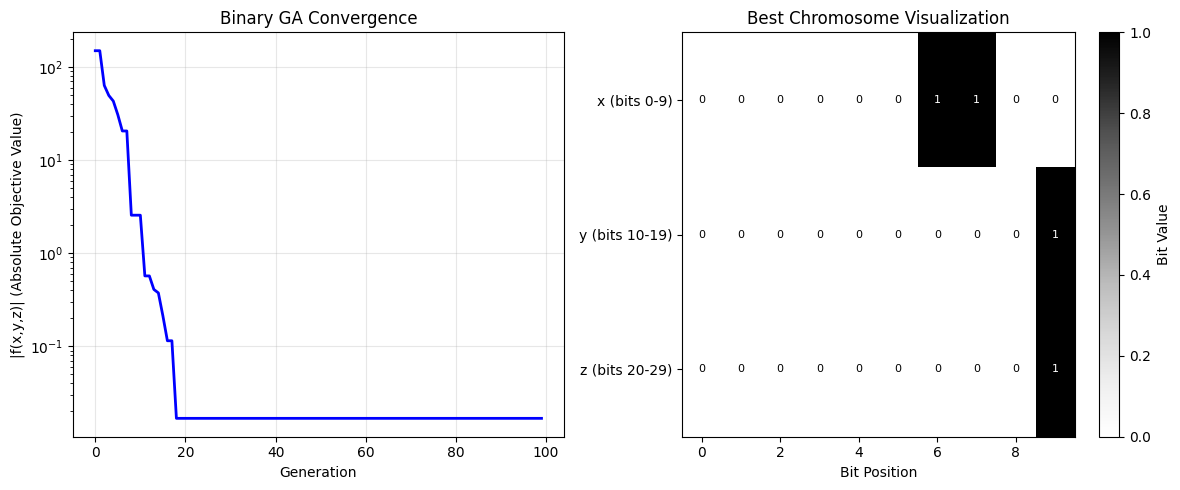

In [48]:
# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Convergence
plt.subplot(1, 2, 1)
plt.plot(hist, 'b-', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('|f(x,y,z)| (Absolute Objective Value)')
plt.title('Binary GA Convergence')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: Chromosome Visualization
plt.subplot(1, 2, 2)
chrom_2d = np.array(best_chrom).reshape(3, 10)
plt.imshow(chrom_2d, cmap='Greys', aspect='auto')
plt.yticks([0, 1, 2], ['x (bits 0-9)', 'y (bits 10-19)', 'z (bits 20-29)'])
plt.xlabel('Bit Position')
plt.title('Best Chromosome Visualization')
plt.colorbar(label='Bit Value')

# Add bit values as text
for i in range(3):
    for j in range(10):
        plt.text(j, i, str(chrom_2d[i, j]), ha='center', va='center', 
                 color='white' if chrom_2d[i, j] == 1 else 'black', fontsize=8)

plt.tight_layout()
plt.show()